# ราคารถมือสอง — Decision Tree (เวอร์ชัน 3)
- ข้อมูล, การรวมชื่อรุ่น และการแบ่ง train/val/test (80 / 10 / 10) เหมือน notebook MLR3 ทุกอย่าง
- ตัวแปรที่ใช้ **ไม่ได้กำหนดเอง** แต่เลือกจาก train ในหัวข้อ 5 (กรองตัวซ้ำซ้อน + permutation importance + backward elimination)
- ทำนาย `log(ราคา)` แต่วัดผลบนราคาจริง
- ไม่ต้องทดสอบ assumption แบบ MLR เพราะต้นไม้ไม่ได้สมมติว่าความสัมพันธ์เป็นเส้นตรงหรือ residual เป็น normal
- notebook นี้รันจากบนลงล่างได้เอง ใช้แค่ไฟล์ CSV

> ต้อง mount Google Drive ก่อนรัน

## 0. Import และค่าตั้งต้น
รวมค่าที่ใช้ทั้ง notebook ไว้ที่เดียว จะได้แก้ง่าย (สัดส่วน train/val/test ก็อยู่ตรงนี้)

In [1]:
import os
import time
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import permutation_importance

DATA_PATH = "/content/drive/MyDrive/Project/cardb/car_dataset_v5.1.csv"
# ใช้รันในเครื่อง: ถ้าไม่เจอ path ของ Drive ให้ใช้ไฟล์ในเครื่องแทน (บน Colab ไม่มีผล)
if not os.path.exists(DATA_PATH):
    DATA_PATH = r"D:\Claude\new_project\data\car_dataset_v5.1.csv"

SEED = 99            # เลขสุ่มคงที่ รันกี่ครั้งก็ได้ผลเหมือนเดิม
MAX_CAR_AGE = 25     # ตัดรถอายุเกิน 25 ปีออก (รถคลาสสิก / รถสะสม)
TRAIN_SIZE = 0.8
VAL_SIZE = 0.1
TEST_SIZE = 0.1

EXPECTED_SHA256 = "d2c6f2c9f6a601406920c9c6fe2da71807137ef4590136f4a621f304f44fa96b"   # ลายนิ้วมือของไฟล์ข้อมูล (ตัด \r ออกก่อนคำนวณ)
REDUNDANT_MAX = 0.95   # คู่ตัวแปรที่สัมพันธ์กันตั้งแต่ค่านี้ขึ้นไป ถือว่าซ้ำซ้อน
TOL = 0.02             # ตัดตัวแปรได้ ถ้า CV MAE แย่ลงไม่เกิน 2%
N_FOLDS = 5            # จำนวน fold ของ cross-validation

NUM_COLS = ["engine_capacity", "mileage", "car_age"]                              # ตัวแปรตัวเลข
CAT_COLS = ["brand", "model", "car_type", "fuel_type", "gear_type", "color"]      # ตัวแปรกลุ่ม

# ชื่อรุ่นที่เขียนต่างกันแต่เป็นรุ่นเดียวกัน
MODEL_ALIASES = {"ALTIS": "COROLLAALTIS", "NP300NAVARA": "NAVARA"}

pd.set_option("display.width", 200, "display.max_columns", 50)

## 1. โหลดข้อมูล
อ่านไฟล์ CSV เข้ามาเป็นตาราง (`DataFrame`) ยังไม่แก้ไขอะไร

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(30104, 11)


,brand,model,car_type,fuel_type,gear_type,color,engine_capacity,mileage,year,car_age,price
0,HONDA,CITY,Sedan,Benzine,Automatic,Red,1000,62000,2020,6,419000
1,FORD,EVEREST,SUV,Diesel,Automatic,White,2000,130000,2012,14,849000
2,HONDA,CIVIC,Hatchback,Benzine,Automatic,Grey,1500,103000,2021,5,759000
3,TOYOTA,FORTUNER,PPV,Diesel,Automatic,Black,2800,57000,2022,4,1069000
4,TOYOTA,ALPHARD,Van,Benzine,Automatic,White,2500,61800,2022,4,2188000


## 2. ตรวจข้อมูล (data check)
ข้อมูลชุดนี้ทำความสะอาดมาแล้ว ขั้นนี้ **แค่ตรวจและรายงาน** ไม่ได้เรียนรู้อะไรจากข้อมูล ไม่แก้ข้อมูล
- ตรวจ **sha256** ของไฟล์ (ลายนิ้วมือของไฟล์) ว่าเป็นไฟล์เวอร์ชันเดียวกับที่ใช้ทำผลทั้งหมด ถ้าไม่ตรงโค้ดจะหยุดทันที (ตัดตัวอักษร `\r` ออกก่อน เพื่อให้ได้ค่าเดียวกันทั้งบน Windows และ Colab)
- ตรวจขนาดตาราง ชนิดข้อมูล (dtypes) ค่าว่าง แถวซ้ำ ค่าต่ำสุด/สูงสุดของตัวเลข
- ตรวจกฎพื้นฐาน: ราคาต้องมากกว่า 0, อายุรถต้องไม่ติดลบ, `year = 2026 - car_age`
- ดูจำนวนค่า (levels) ของตัวแปรกลุ่มแต่ละตัว

In [3]:
with open(DATA_PATH, "rb") as f:
    file_hash = hashlib.sha256(f.read().replace(b"\r", b"")).hexdigest()
assert file_hash == EXPECTED_SHA256, f"ไฟล์ข้อมูลไม่ตรงกับเวอร์ชันที่ใช้ทำผล (sha256 ที่ได้ = {file_hash})"
print("sha256 ตรงกับไฟล์ที่คาดไว้:", file_hash[:16], "...")

print("\nshape:", df.shape)
print("\ndtypes:"); print(df.dtypes.to_string())
print("\nค่าว่างต่อคอลัมน์:"); print(df.isna().sum().to_string())
print("\nแถวซ้ำทั้งแถว:", int(df.duplicated().sum()))
print("\nค่าต่ำสุด / สูงสุดของตัวเลข:")
print(df.select_dtypes("number").agg(["min", "max"]).T.to_string())

assert (df["price"] > 0).all(), "มีราคาที่ไม่เป็นบวก"
assert (df["car_age"] >= 0).all(), "มีอายุรถติดลบ"
assert (df["year"] == 2026 - df["car_age"]).all(), "year ไม่เท่ากับ 2026 - car_age"
print("\nผ่าน: price > 0, car_age >= 0, year == 2026 - car_age ทุกแถว")

print("\nจำนวน levels ของตัวแปรกลุ่ม:")
print(df[CAT_COLS].nunique().to_string())

sha256 ตรงกับไฟล์ที่คาดไว้: d2c6f2c9f6a60140 ...

shape: (30104, 11)

dtypes:
brand                str
model                str
car_type             str
fuel_type            str
gear_type            str
color                str
engine_capacity    int64
mileage            int64
year               int64
car_age            int64
price              int64

ค่าว่างต่อคอลัมน์:
brand              0
model              0
car_type           0
fuel_type          0
gear_type          0
color              0
engine_capacity    0
mileage            0
year               0
car_age            0
price              0

แถวซ้ำทั้งแถว: 0

ค่าต่ำสุด / สูงสุดของตัวเลข:
                   min       max
engine_capacity    600      6800
mileage              1    746754
year              1950      2026
car_age              0        76
price            25000  26800000

ผ่าน: price > 0, car_age >= 0, year == 2026 - car_age ทุกแถว

จำนวน levels ของตัวแปรกลุ่ม:
brand         54
model        552
car_type       7
fuel_ty

## 3. เตรียมแถวข้อมูล
- ตัดรถอายุเกิน 25 ปี (เป็นรถสะสม ราคาไม่ตามกฎปกติ)
- ตัดคอลัมน์ `year` ทิ้ง เพราะ `year = 2026 - car_age` พอดี (ตรวจในขั้น 2 แล้ว) ข้อมูลซ้ำกันเป๊ะ ๆ
- รวมชื่อรุ่นที่สะกดต่างกัน เพื่อไม่ให้รุ่นเดียวกันถูกนับเป็นหลายรุ่น

In [4]:
rows_before = len(df)
df = df[df["car_age"] <= MAX_CAR_AGE]
print(f"ตัดรถอายุเกิน {MAX_CAR_AGE} ปี: {rows_before - len(df)} แถว")

# year = 2026 - car_age พอดี จึงเป็นข้อมูลซ้ำ ตัดทิ้ง
df = df.drop(columns="year")

# รวมชื่อรุ่นที่เขียนต่างกัน (เช่น "CR-V" กับ "CRV"):
# ทำเป็นตัวพิมพ์ใหญ่ ตัดช่องว่าง/ขีดออก แล้วใช้ชื่อที่พบบ่อยที่สุดในกลุ่มนั้นเป็นชื่อเดียว
model_key = df["model"].str.upper().str.replace(r"[^A-Z0-9]", "", regex=True).replace(MODEL_ALIASES)
most_common_name = df.groupby(model_key)["model"].agg(lambda names: names.value_counts().index[0])
df["model"] = model_key.map(most_common_name)
print(df.shape)

ตัดรถอายุเกิน 25 ปี: 287 แถว


(29817, 10)


## 4. แบ่ง train / val / test (80 / 10 / 10)
- `train` ใช้สอนโมเดล (และเลือกตัวแปร), `val` ใช้เลือก hyperparameter / ตรวจโมเดล, `test` ใช้วัดผลสุดท้ายครั้งเดียว
- สุ่มรถ 1 คันจากทุกรุ่นใส่ train ก่อน เพื่อให้โมเดลเคยเห็นทุกรุ่น แล้วเติม train ให้ครบตามสัดส่วน ส่วนที่เหลือแบ่งครึ่งต่อครึ่งเป็น val กับ test

In [5]:
# ขั้น 1: สุ่มรถ 1 คันจากทุก (ยี่ห้อ, รุ่น) ไว้ใน train
forced = df.groupby(["brand", "model"]).sample(n=1, random_state=SEED)
rest = df.drop(forced.index)

# ขั้น 2: แบ่งส่วนที่เหลือ ให้ train รวมแล้วได้ TRAIN_SIZE ของทั้งหมด
train_rest, temp = train_test_split(rest, train_size=round(TRAIN_SIZE * len(df)) - len(forced), random_state=SEED)
train = pd.concat([forced, train_rest])

# ขั้น 3: แบ่งส่วนที่เหลือครึ่งต่อครึ่ง เป็น val กับ test
val, test = train_test_split(temp, test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE), random_state=SEED)

print("train / val / test:", len(train), len(val), len(test))

train / val / test: 23854 2981 2982


## 5. เลือกตัวแปร (variable selection) — ใช้เฉพาะ train
ไม่ได้ใส่ตัวแปรทุกตัวเข้าโมเดลตรง ๆ แต่ให้ข้อมูลช่วยเลือก ทำ 2 ชั้น โดยใช้ **train เท่านั้น** (val/test ไม่ถูกแตะ):

| ชั้น | ทำอะไร |
|---|---|
| 1. กรองตัวแปรซ้ำซ้อน (redundancy filter) | ดูทุกคู่ตัวแปร ถ้าสัมพันธ์กันเกิน 0.95 ถือว่าซ้ำกัน ตัดออกหนึ่งตัวในคู่ |
| 2. เลือกตามวิธีของโมเดลนั้น | MLR: GVIF + ตัดแบบถอยหลัง (backward elimination) ด้วย F-test และ CV MAE / ต้นไม้: permutation importance + ตัดแบบถอยหลัง |

### 5.1 ชั้น 1: กรองความซ้ำซ้อน
วัดความสัมพันธ์ของแต่ละคู่ให้อยู่ในช่วง 0-1 เหมือนกันหมด จะได้ใช้เกณฑ์เดียว (`REDUNDANT_MAX` = 0.95):
- **ตัวเลข x ตัวเลข:** |Pearson r|
- **กลุ่ม x กลุ่ม:** Cramér's V (แบบปรับ bias ของ Bergsma 2013) V ไม่บอกทิศทาง จึงใช้ **Theil's U** ช่วย: U(a|b) = สัดส่วนความไม่แน่นอนของ a ที่ b อธิบายได้ ถ้า U(a|b) ≈ 1 แปลว่า b มีข้อมูลของ a อยู่แล้ว ตัด a (ตัวที่หยาบกว่า)
- **ตัวเลข x กลุ่ม:** correlation ratio η (รากของสัดส่วนความแปรปรวนของตัวเลขที่กลุ่มอธิบายได้)

**ใครโดนตัดอะไร:** คู่ที่เกือบซ้ำ (>= 0.95 แต่ไม่ถึง 1) เป็นปัญหาของ **MLR เท่านั้น** เพราะตัวแปรที่สัมพันธ์กันทำให้ค่าสัมประสิทธิ์ไม่นิ่ง ต้นไม้ไม่เดือดร้อน และตัวแปรที่หยาบกว่า (เช่น `brand`) ยังช่วยต้นไม้ได้ ต้นไม้จึงตัดเฉพาะตัวที่ซ้ำกัน **เป๊ะ** (|r| = 1) แล้วให้ชั้น 2 ตัดสินส่วนที่เหลือ (ที่นี่ `year` ซึ่งซ้ำกับ `car_age` เป๊ะถูกตัดไปแล้วในขั้น 3 จึงไม่มีคู่ที่ซ้ำเป๊ะเหลือ)

In [6]:
def entropy(x):
    p = x.value_counts(normalize=True)
    return -(p * np.log(p)).sum()


def theil_u(a, b):
    """U(a|b): สัดส่วน entropy ของ a ที่ b อธิบายได้ (1 = b กำหนด a ได้หมด)"""
    return 1 - sum(len(g) / len(a) * entropy(g) for _, g in a.groupby(b)) / entropy(a)


def cramers_v(a, b):
    """Cramér's V แบบปรับ bias (Bergsma 2013)"""
    t = pd.crosstab(a, b)
    n = t.values.sum()
    r, k = t.shape
    phi2 = max(0, stats.chi2_contingency(t, correction=False)[0] / n - (k - 1) * (r - 1) / (n - 1))
    r_corr, k_corr = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / min(k_corr - 1, r_corr - 1))


def eta(x, group):
    """correlation ratio: ตัวเลข x ถูกอธิบายด้วยกลุ่ม group ได้เท่าไร"""
    m = x.mean()
    return np.sqrt(sum(len(s) * (s.mean() - m) ** 2 for _, s in x.groupby(group)) / ((x - m) ** 2).sum())


rows = []
for i, a in enumerate(NUM_COLS):
    for b in NUM_COLS[i + 1:]:
        rows.append(dict(a=a, b=b, measure="|r|", value=abs(train[a].corr(train[b]))))
for i, a in enumerate(CAT_COLS):
    for b in CAT_COLS[i + 1:]:
        rows.append(dict(a=a, b=b, measure="Cramér's V", value=cramers_v(train[a], train[b]),
                         U_a_given_b=theil_u(train[a], train[b]), U_b_given_a=theil_u(train[b], train[a])))
for a in NUM_COLS:
    for b in CAT_COLS:
        rows.append(dict(a=a, b=b, measure="η", value=eta(train[a], train[b])))
pairs = pd.DataFrame(rows).sort_values("value", ascending=False)
pairs["redundant"] = pairs["value"] >= REDUNDANT_MAX
pairs.round(3).head(15)

,a,b,measure,value,U_a_given_b,U_b_given_a,redundant
3,brand,model,Cramér's V,0.987,1.000,0.514,True
8,model,car_type,Cramér's V,0.970,0.350,0.961,True
19,engine_capacity,model,η,0.931,NaN,NaN,False
9,model,fuel_type,Cramér's V,0.836,0.155,0.750,False
10,model,gear_type,Cramér's V,0.734,0.044,0.615,False
13,car_type,gear_type,Cramér's V,0.683,0.101,0.513,False
20,engine_capacity,car_type,η,0.615,NaN,NaN,False
31,car_age,model,η,0.613,NaN,NaN,False
12,car_type,fuel_type,Cramér's V,0.559,0.198,0.348,False
21,engine_capacity,fuel_type,η,0.550,NaN,NaN,False


**การตัดสินใจ:** ในแต่ละคู่ที่ซ้ำซ้อน ตัดตัวที่อีกตัวมีข้อมูลของมันอยู่แล้ว
- คู่ตัวเลข: ตัดตัวหลัง (`b`)
- คู่กลุ่ม: ตัด `a` ถ้า U(a|b) > U(b|a) ไม่งั้นตัด `b` (ตัดตัวที่หยาบกว่า)
- คู่ η ที่เกินเกณฑ์: ให้คนตัดสินเอง (โค้ดจะหยุดเตือน)

In [7]:
dropped = {}
for _, p in pairs[pairs.redundant].iterrows():
    if p.measure == "|r|":
        victim = p.b
    elif p.measure == "Cramér's V":
        victim = p.a if p.U_a_given_b > p.U_b_given_a else p.b
    else:
        raise ValueError(f"คู่ η เกินเกณฑ์ ต้องตัดสินใจเอง: {p.a} x {p.b}")
    dropped.setdefault(victim, f"{p.a} x {p.b}: {p.measure} = {p.value:.3f}")

ALL_VARS = NUM_COLS + CAT_COLS
LAYER1_MLR = [c for c in ALL_VARS if c not in dropped]        # MLR: ตัดทุกคู่ที่ซ้ำซ้อน
exact_dup = pairs[(pairs.measure == "|r|") & (pairs.value > 1 - 1e-9)]
LAYER1_TREE = [c for c in ALL_VARS if c not in set(exact_dup["b"])]   # ต้นไม้: ตัดเฉพาะตัวที่ซ้ำกันเป๊ะ

print("ตัวแปรที่ถูกตัดในชั้น 1 (MLR):")
print(pd.Series(dropped, name="ตัดเพราะ").to_string() if dropped else "  (ไม่มี)")
print("\nMLR   -> ไปชั้น 2:", LAYER1_MLR)
print("ต้นไม้ -> ไปชั้น 2:", LAYER1_TREE)

ตัวแปรที่ถูกตัดในชั้น 1 (MLR):
brand          brand x model: Cramér's V = 0.987
car_type    model x car_type: Cramér's V = 0.970

MLR   -> ไปชั้น 2: ['engine_capacity', 'mileage', 'car_age', 'model', 'fuel_type', 'gear_type', 'color']
ต้นไม้ -> ไปชั้น 2: ['engine_capacity', 'mileage', 'car_age', 'brand', 'model', 'car_type', 'fuel_type', 'gear_type', 'color']


### 5.2 ชั้น 2: เลือกตามวิธีของโมเดล
เริ่มจากตัวแปรที่เหลือจากชั้น 1 ทุกตัวเลขในส่วนนี้ใช้ **train เท่านั้น** กับ `KFold(5, shuffle=True, random_state=99)` (cross-validation: แบ่ง train เป็น 5 ส่วน สลับกันเป็นส่วนสอบ)
- target คือ `log(ราคา)` ทุกโมเดล แต่ CV MAE วัดบน **ราคาจริง (บาท)**
- `TOL` = 2%: การตัดตัวแปรหนึ่งตัวยอมให้ CV MAE แย่ลงได้ไม่เกิน 2% **เทียบกับตอนใช้ตัวแปรครบ** (ไม่ใช่เทียบรอบก่อน) ดังนั้นตัดไปหลายรอบรวมแล้วก็แย่ลงไม่เกิน 2%

In [8]:
folds = list(KFold(N_FOLDS, shuffle=True, random_state=SEED).split(train))
y_log = np.log(train["price"]).values   # target ที่ใช้ตอนเลือกตัวแปร
price = train["price"].values           # ราคาจริง ไว้วัด MAE

### 5.2 ชั้น 2 สำหรับ Decision Tree: permutation importance + backward elimination
ต้นไม้ไม่มี p-value จึงวัดความสำคัญของตัวแปรโดยตรงด้วย **permutation importance**: สลับค่าของตัวแปรนั้นแบบสุ่มใน fold ที่ไว้สอบ แล้วดูว่า MAE (บนราคาจริง) แย่ลงเท่าไร (5 fold x สลับ 5 ครั้ง = 25 ค่าต่อตัวแปร)
- ไม่ใช้ built-in importance เพราะคำนวณบน train และเอนเอียงไปทางตัวแปรที่มีหลายค่า (`model` ~500 ค่า, `mileage`)
- แต่ละรอบ ตัวแปรที่สำคัญน้อยที่สุดจะถูกตัด **ก็ต่อเมื่อ** (1) ความสำคัญแยกจาก 0 ไม่ออก คือ ค่าเฉลี่ย − 2·SD <= 0 **และ** (2) CV MAE ตอนไม่มีมัน แย่ลงไม่เกิน `TOL` เมื่อเทียบกับตอนมีครบ ถ้าไม่เข้าเงื่อนไขก็หยุด
- hyperparameter ตอนเลือกตัวแปรกำหนดคงที่ (การเลือกตัวแปรไม่ควรขึ้นกับการจูน) แล้วหัวข้อ 7 ค่อยจูนใหม่บนตัวแปรที่เลือกได้
- การแปลงตัวแปร: Decision Tree ต้องการตัวเลข จึงแปลงตัวแปรกลุ่ม (เช่น brand) เป็นรหัสตัวเลข 0, 1, 2, ...; ค่าที่ train ไม่เคยเห็นจะได้ -1

In [9]:
def make_model():
    return DecisionTreeRegressor(max_depth=20, min_samples_leaf=5, random_state=SEED)


USE_CODES = True   # True = แปลงตัวแปรกลุ่มเป็นรหัสตัวเลข, False = pd.Categorical
rng = np.random.default_rng(SEED)


def encode(d, fit_d, variables):
    """เลือกคอลัมน์ แล้วแปลงตัวแปรกลุ่มโดยใช้ levels จาก fit_d (ค่าที่ไม่เคยเห็นจะเป็น -1 หรือ NaN)"""
    X = d[variables].copy()
    for col in [c for c in variables if c in CAT_COLS]:
        levels = sorted(fit_d[col].unique())
        X[col] = pd.Categorical(d[col].where(d[col].isin(levels)), categories=levels)
        if USE_CODES:
            X[col] = X[col].cat.codes
    return X


def cv_mae(variables, with_importance=True):
    """CV MAE (ราคาจริง) และ permutation importance ของทุกตัวแปร (MAE ที่เพิ่มขึ้นเมื่อสลับค่า)"""
    maes = []
    importance = {v: [] for v in variables}
    for tr, va in folds:
        fold_train, fold_val = train.iloc[tr], train.iloc[va]
        model = make_model().fit(encode(fold_train, fold_train, variables), y_log[tr])
        X_val_fold = encode(fold_val, fold_train, variables)
        fold_mae = lambda X: np.abs(np.exp(model.predict(X)) - price[va]).mean()
        maes.append(fold_mae(X_val_fold))
        if with_importance:
            for v in variables:
                for _ in range(5):
                    X_shuffled = X_val_fold.copy()
                    X_shuffled[v] = X_shuffled[v].values[rng.permutation(len(X_shuffled))]
                    importance[v].append(fold_mae(X_shuffled) - maes[-1])
    if not with_importance:
        return np.mean(maes), None
    table = pd.DataFrame({"importance": {v: np.mean(s) for v, s in importance.items()},
                          "SD": {v: np.std(s) for v, s in importance.items()}})
    return np.mean(maes), table


start = time.time()
current = LAYER1_TREE.copy()
base_mae, imp_table = cv_mae(current)
selection_log = []
while len(current) > 1:
    imp_table["lower"] = imp_table["importance"] - 2 * imp_table["SD"]
    weakest = imp_table["importance"].idxmin()
    mae_without, _ = cv_mae([v for v in current if v != weakest], with_importance=False)
    loss = mae_without / base_mae - 1
    can_drop = bool(imp_table.loc[weakest, "lower"] <= 0 and loss <= TOL)
    selection_log.append(imp_table.sort_values("importance", ascending=False)
                         .assign(round=len(selection_log) + 1, weakest=lambda s: s.index == weakest,
                                 cv_MAE_without_weakest=mae_without, loss_vs_all=loss,
                                 dropped=lambda s: (s.index == weakest) & can_drop))
    print(f"รอบ {len(selection_log)}: ตัวอ่อนสุด = {weakest}, CV MAE ถ้าตัด = {mae_without:,.0f} ({loss:+.2%}) -> {'ตัด' if can_drop else 'หยุด'}")
    if not can_drop:
        break
    current.remove(weakest)
    _, imp_table = cv_mae(current)

SELECTED = current
FEATURES = SELECTED
CAT_SEL = [c for c in FEATURES if c in CAT_COLS]
print(f"\nใช้เวลา {time.time() - start:.0f} วินาที | CV MAE ตอนมีครบ {base_mae:,.0f}")
print("ตัวแปรที่เลือก:", SELECTED)
print("ตัวแปรที่ถูกตัด:", [v for v in LAYER1_TREE if v not in SELECTED])
pd.concat(selection_log).reset_index(names="variable").set_index(["round", "variable"]).round(4)

รอบ 1: ตัวอ่อนสุด = color, CV MAE ถ้าตัด = 106,634 (-1.31%) -> หยุด

ใช้เวลา 3 วินาที | CV MAE ตอนมีครบ 108,047
ตัวแปรที่เลือก: ['engine_capacity', 'mileage', 'car_age', 'brand', 'model', 'car_type', 'fuel_type', 'gear_type', 'color']
ตัวแปรที่ถูกตัด: []


importance          SD        lower  weakest  cv_MAE_without_weakest  loss_vs_all  dropped
round variable                                                                                                    
1     engine_capacity  259769.6621  12745.2013  234279.2595    False             106634.3053      -0.0131    False
      car_age          173577.9696   6395.4781  160787.0133    False             106634.3053      -0.0131    False
      model            102599.4041   9021.7099   84555.9842    False             106634.3053      -0.0131    False
      car_type          99837.4063   9914.8688   80007.6688    False             106634.3053      -0.0131    False
      brand             68108.1894   8462.3156   51183.5583    False             106634.3053      -0.0131    False
      mileage           40712.8784   4664.9889   31382.9006    False             106634.3053      -0.0131    False
      fuel_type         29596.1547   2672.2190   24251.7166    False             106634.3053      -0.0131    False
      gear_type         10262.6019   2484.5704    5293.4612    False             106634.3053      -0.0131    False
      color              2080.5852    672.7899     735.0055     True             106634.3053      -0.0131    False

## 6. เตรียมตัวแปร (features) และ target
ใช้เฉพาะตัวแปรที่เลือกในหัวข้อ 5 (`FEATURES`)
- Decision Tree ต้องการตัวเลข จึงแปลงตัวแปรกลุ่ม (เช่น brand) เป็นรหัสตัวเลข 0, 1, 2, ...; ค่าที่ train ไม่เคยเห็นจะได้ -1
- levels สร้างจาก train เท่านั้น
- **target เป็น `log(ราคา)`**: ราคารถกระจายเบ้ขวา (รถแพงมากดึงค่า) การเรียน log ทำให้โมเดลสนใจความผิดพลาดแบบ "เป็น %" มากกว่า "เป็นบาท" แล้วค่อย `exp` กลับเป็นบาทตอนวัดผล (back-transform)

In [10]:
def make_features(data):
    """เลือกคอลัมน์ที่ใช้ แล้วแปลงตัวแปรกลุ่ม (ค่าที่ไม่มีใน train จะได้ -1 หรือ NaN)"""
    return encode(data, train, FEATURES)


X_train = make_features(train)
X_val = make_features(val)
X_test = make_features(test)
y_train_log = np.log(train["price"])   # ให้โมเดลเรียนรู้ log(ราคา)
print(X_train.shape, "| ตัวแปร:", FEATURES)

(23854, 9) | ตัวแปร: ['engine_capacity', 'mileage', 'car_age', 'brand', 'model', 'car_type', 'fuel_type', 'gear_type', 'color']


## 7. ฟังก์ชันวัดผล
ใช้ 4 ตัวชี้วัด (คำนวณบนราคาจริงเป็นบาท):
- **RMSE** = รากของค่าเฉลี่ย error ยกกำลังสอง ลงโทษ error ใหญ่ ๆ หนัก (หน่วยบาท ยิ่งน้อยยิ่งดี)
- **MAE** = ค่าเฉลี่ยของ error แบบไม่สนทิศทาง อ่านง่าย "พลาดเฉลี่ยกี่บาท" (ยิ่งน้อยยิ่งดี)
- **MAPE** = error เฉลี่ยเป็นสัดส่วนของราคาจริง เช่น 0.11 = พลาดเฉลี่ย 11% (ยิ่งน้อยยิ่งดี)
- **R²** = โมเดลอธิบายความผันผวนของราคาได้กี่ส่วน (1 = สมบูรณ์แบบ, 0 = ไม่ดีกว่าทายค่าเฉลี่ย)

In [11]:
def score(actual, predicted):
    """วัดผลบนราคาจริง (บาท)"""
    return {
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "MAE": mean_absolute_error(actual, predicted),
        "MAPE": np.mean(np.abs(predicted / actual - 1)),
        "R2": r2_score(actual, predicted),
    }

## 8. ลองหลาย config แล้ววัดผลบน validation
**hyperparameter** คือค่าที่เราตั้งเองก่อนสอนโมเดล เราลองหลายชุด (grid) แล้วดูผลบน val ยังไม่แตะ test ในขั้นนี้
- `max_depth` = ความลึกสูงสุดของต้นไม้ (20 หรือไม่จำกัด)
- `min_samples_leaf` = จำนวนรถขั้นต่ำในใบ (1, 5, 10) ยิ่งมากยิ่งไม่ overfit
- `ccp_alpha` = ตัวตัดกิ่ง (pruning) ยิ่งมากยิ่งตัดกิ่งเยอะ ต้นไม้เล็กลง

`gap` = val MAE / train MAE (ยิ่งใกล้ 1 ยิ่ง overfit น้อย)

In [12]:
results = []
trees = []
for max_depth in [20, None]:
    for min_samples_leaf in [1, 5, 10]:
        for ccp_alpha in [0, 1e-5, 3e-5, 1e-4]:
            params = {"max_depth": max_depth, "min_samples_leaf": min_samples_leaf, "ccp_alpha": ccp_alpha}
            tree = DecisionTreeRegressor(**params, random_state=SEED)
            tree.fit(X_train, y_train_log)

            # โมเดลทายเป็น log(ราคา) จึงต้อง exp กลับเป็นราคาก่อนวัดผล
            row = score(val["price"], np.exp(tree.predict(X_val)))
            row["train_MAE"] = mean_absolute_error(train["price"], np.exp(tree.predict(X_train)))
            row["gap"] = row["MAE"] / row["train_MAE"]
            row["params"] = str(params)
            results.append(row)
            trees.append(tree)

tune = pd.DataFrame(results)
tune.sort_values("MAE").round(4)

,RMSE,MAE,MAPE,R2,train_MAE,gap,params
13,235510.2308,89503.5398,0.1349,0.8927,65298.2940,1.3707,"{'max_depth': None, 'min_samples_leaf': 1, 'cc..."
1,243444.9265,90924.3327,0.1369,0.8854,65312.7419,1.3921,"{'max_depth': 20, 'min_samples_leaf': 1, 'ccp_..."
12,235204.4828,92148.0439,0.1492,0.8930,394.8185,233.3934,"{'max_depth': None, 'min_samples_leaf': 1, 'cc..."
0,251158.5912,93576.1752,0.1486,0.8780,6284.3596,14.8903,"{'max_depth': 20, 'min_samples_leaf': 1, 'ccp_..."
16,274319.2846,95539.4529,0.1384,0.8545,69078.3963,1.3831,"{'max_depth': None, 'min_samples_leaf': 5, 'cc..."
4,274907.2804,95793.3743,0.1386,0.8538,69152.9168,1.3852,"{'max_depth': 20, 'min_samples_leaf': 5, 'ccp_..."
17,270843.6594,96356.1807,0.1394,0.8581,81178.4181,1.1870,"{'max_depth': None, 'min_samples_leaf': 5, 'cc..."
5,271452.9658,96623.0992,0.1397,0.8575,81178.4181,1.1903,"{'max_depth': 20, 'min_samples_leaf': 5, 'ccp_..."
8,268290.6686,97514.8416,0.1444,0.8608,86629.3781,1.1257,"{'max_depth': 20, 'min_samples_leaf': 10, 'ccp..."
20,268290.6686,97514.8416,0.1444,0.8608,86629.3781,1.1257,"{'max_depth': None, 'min_samples_leaf': 10, 'c..."


## 9. เลือก config ที่ดีที่สุด แล้ววัดผลบน test (ครั้งเดียว)
**กฎ `pick`**: เอา config ที่ val MAE ห่างจากตัวที่ดีที่สุดไม่เกิน 2% มาเป็นกลุ่ม แล้วเลือกตัวที่ `gap` ต่ำสุด
(แม่นใกล้เคียงที่สุด และ overfit น้อยที่สุด) เพราะความต่างแค่ 2% มักเป็นแค่ความบังเอิญ แต่ overfit น้อยกว่าคือข้อดีจริง

In [13]:
near_best = tune[tune["MAE"] <= tune["MAE"].min() * 1.02]
best_i = near_best["gap"].idxmin()
best_tree = trees[best_i]
print("config ที่เลือก:", tune.loc[best_i, "params"])

test_pred = np.exp(best_tree.predict(X_test))
this_test = {"model": "Decision Tree", **score(test["price"], test_pred),
             "params": tune.loc[best_i, "params"], "train_MAE": tune.loc[best_i, "train_MAE"],
             "val_MAE": tune.loc[best_i, "MAE"], "val_R2": tune.loc[best_i, "R2"]}
pd.DataFrame([this_test]).set_index("model").round(4)

config ที่เลือก: {'max_depth': None, 'min_samples_leaf': 1, 'ccp_alpha': 1e-05}


,RMSE,MAE,MAPE,R2,params,train_MAE,val_MAE,val_R2
model,,,,,,,,
Decision Tree,231127.8162,83953.232,0.134,0.8677,"{'max_depth': None, 'min_samples_leaf': 1, 'cc...",65298.294,89503.5398,0.8927


## 10. ราคาจริง vs ราคาที่ทำนาย (test)
จุดยิ่งใกล้เส้นประสีแดง ยิ่งทายแม่น (แกนเป็นสเกล log เพื่อให้เห็นทั้งรถถูกและรถแพง)

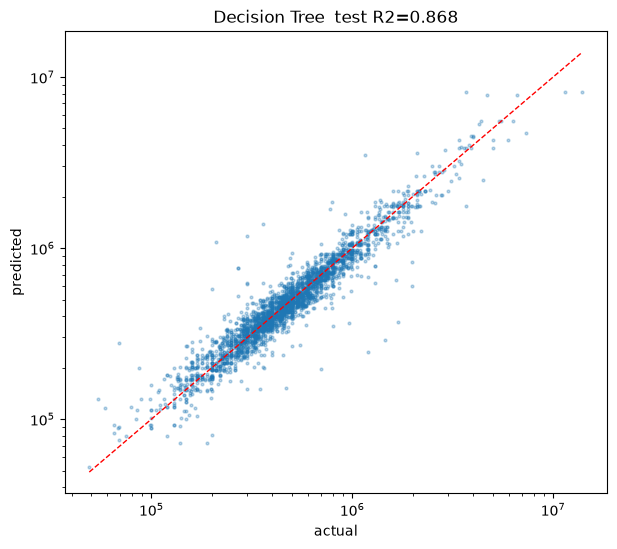

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(test["price"], test_pred, s=4, alpha=0.3)
price_range = [test["price"].min(), test["price"].max()]
ax.plot(price_range, price_range, "r--", lw=1)   # เส้นที่ทายถูกพอดี
ax.set(xscale="log", yscale="log", xlabel="actual", ylabel="predicted",
       title=f"Decision Tree  test R2={r2_score(test['price'], test_pred):.3f}")
plt.show()

## 11. ตัวแปรไหนสำคัญ
- `built-in` = ค่าที่โมเดลคำนวณเอง มักให้น้ำหนักเกินกับตัวแปรที่มีหลายค่า (`model` มี ~490 รุ่น)
- `permutation (val)` = สลับค่าของตัวแปรนั้นแบบสุ่มบน val แล้วดูว่าผลแย่ลงแค่ไหน (น่าเชื่อถือกว่า)

In [15]:
perm = permutation_importance(best_tree, X_val, np.log(val["price"]), n_repeats=5, random_state=SEED, n_jobs=-1)
importance = pd.DataFrame({"built-in": best_tree.feature_importances_, "permutation (val)": perm.importances_mean},
                          index=FEATURES)
importance = importance / importance.sum()   # ทำให้แต่ละคอลัมน์รวมกันได้ 1
importance.sort_values("permutation (val)", ascending=False).round(3)

,built-in,permutation (val)
engine_capacity,0.302,0.328
car_age,0.346,0.279
model,0.087,0.130
car_type,0.102,0.114
brand,0.072,0.091
fuel_type,0.024,0.027
mileage,0.054,0.017
gear_type,0.009,0.014
color,0.004,0.001


## 12. ทายพลาดตรงไหน (validation)
แยกตามอายุรถ และ 15 รุ่นที่พลาดมากที่สุด (เฉพาะรุ่นที่มีอย่างน้อย 10 คัน)

In [16]:
errors = val.copy()
errors["pred"] = np.exp(best_tree.predict(X_val))
errors["abs_err"] = (errors["pred"] - errors["price"]).abs()   # พลาดกี่บาท
errors["ape"] = errors["abs_err"] / errors["price"]            # พลาดกี่ % ของราคา
errors["age_bin"] = pd.cut(errors["car_age"], [-1, 2, 5, 8, 12, 16, 20, 25])

by_age = errors.groupby("age_bin", observed=True).agg(
    n=("ape", "size"), MAE=("abs_err", "mean"), MAPE=("ape", "mean"))
display(by_age.round(3))

by_model = errors.groupby(["brand", "model"]).agg(
    n=("ape", "size"), MAE=("abs_err", "mean"), MAPE=("ape", "mean"), med_price=("price", "median"))
by_model = by_model[by_model["n"] >= 10]
by_model.sort_values("MAE", ascending=False).head(15).round(3)

,n,MAE,MAPE
age_bin,,,
"(-1, 2]",176,166536.052,0.127
"(2, 5]",842,112841.719,0.118
"(5, 8]",879,82365.160,0.118
"(8, 12]",649,69526.533,0.142
"(12, 16]",314,60296.599,0.183
"(16, 20]",82,49035.857,0.218
"(20, 25]",39,51569.516,0.244


,,n,MAE,MAPE,med_price
brand,model,,,,
PORSCHE,CAYENNE,20,337531.713,0.126,2940000.0
MERCEDES-BENZ,E300,10,266382.907,0.214,1224500.0
BMW,530E,22,235580.104,0.205,979000.0
MERCEDES-BENZ,C220,13,231903.480,0.185,1490000.0
TOYOTA,HIACE,20,224636.176,0.318,679000.0
BMW,330E,11,216058.117,0.198,1090000.0
HYUNDAI,STARIA,12,184528.858,0.165,1049500.0
TOYOTA,ALPHARD,41,163253.840,0.099,1675000.0
MERCEDES-BENZ,C350,16,151082.047,0.183,584500.0
